In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
methylamine,31.06,2.5078,2.8459,209.89,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,methylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
methylamine,H,methylamine,e,616.25,0.11825
water,H,water,e,2425.67,0.045
methylamine,H,water,e,1520.96,0.072945
methylamine,e,water,H,1520.96,0.072945
"""

model = PCSAFT(["water", "methylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 275.2846976834346; 275.2846976834346 209.89]
[2.8014570000000003e-10 2.8236785e-10; 2.8236785e-10 2.8459e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [10]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 250.,
        :upper   => 350.0,
        :guess   => 275.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 350.0, :param => :epsilon, :indices => (1, 2), :guess => 275.0, :lower => 250.0)

In [11]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_methylamine.csv")
fix_line_endings("vley_methylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_methylamine.csv"
        "vley_methylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_methylamine.csv
Fixed: vley_methylamine.csv
Initial objective value: 0.8334024819632218


In [12]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([327.186904079277], PCSAFT{BasicIdeal, Float64}("water", "methylamine"))

In [13]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 327.186904079277; 327.186904079277 209.89]
[2.8014570000000003e-10 2.8236785e-10; 2.8236785e-10 2.8459e-10]
kij = -0.20042550821362015


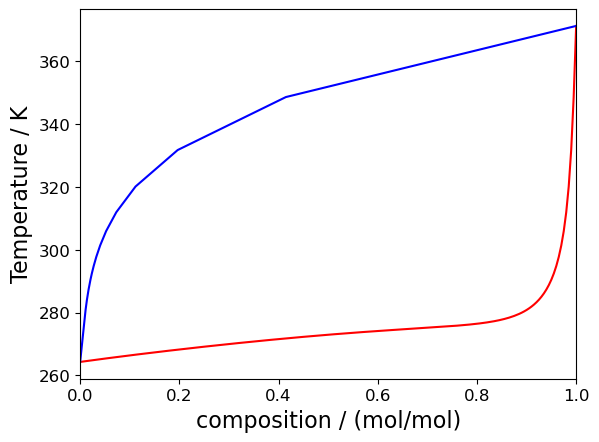

([240.0, 260.0, 280.0, 300.0, 320.0, 340.0, 360.0, 380.0], PyCall.PyObject[PyObject Text(0, 240.0, '240'), PyObject Text(0, 260.0, '260'), PyObject Text(0, 280.0, '280'), PyObject Text(0, 300.0, '300'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 380.0, '380')])

In [14]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 93300

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="blue")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
     

In [15]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [16]:
aard_p   = calculate_AAD(model_opt, "vlep_methylamine.csv", vle_p)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vlep_methylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.5055      288.670000    287.520822    0.3981  
0.5636      294.020000    293.260153    0.2584  
0.6138      299.710000    299.375916    0.1115  
0.6522      304.890000    304.940645    0.0166  
0.6906      310.820000    311.410994    0.1901  
0.7179      315.960000    316.627669    0.2113  
0.7433      320.630000    321.972025    0.4186  
0.7654      325.590000    327.008629    0.4357  
0.7830      329.860000    331.262164    0.4251  
0.7999      334.210000    335.522391    0.3927  
0.8175      339.460000    340.098275    0.1880  
0.8331      343.330000    344.220048    0.2592  
0.8479      347.510000    348.129309    0.1782  
0.8601      351.510000    351.304942    0.0583  
0.8704      353.850000    353.921252    0.0201  
0.8800      356.420000    356.282581    0.0386  
0.9039      362.240000    361.703111    0.1482  
0.9120      364.350000    363.353635    0.2735  
0.9191      365.350000   

0.202008729279188

In [17]:
aard_p   = calculate_AAD(model_opt, "vley_methylamine.csv", vle_y)


=== AAD: vley_methylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.5055      0.005200      0.004099      21.1708 
0.5636      0.008700      0.007264      16.5107 
0.6138      0.014300      0.012519      12.4546 
0.6522      0.021500      0.019659      8.5640  
0.6906      0.033100      0.031867      3.7259  
0.7179      0.046900      0.045788      2.3720  
0.7433      0.063200      0.064984      2.8221  
0.7654      0.085500      0.088851      3.9195  
0.7830      0.109700      0.114397      4.2819  
0.7999      0.140000      0.145959      4.2566  
0.8175      0.181100      0.187827      3.7143  
0.8331      0.227400      0.233945      2.8783  
0.8479      0.281100      0.286396      1.8841  
0.8601      0.334000      0.336259      0.6763  
0.8704      0.384000      0.382920      0.2813  
0.8800      0.434600      0.429893      1.0832  
0.9039      0.573300      0.558205      2.6330  
0.9120      0.622200      0.603925      2.9372  
0.9191      0.664800     

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


4.668865287451093